In [1]:
!pip install pvlib

In [2]:
import numpy as np
import pandas as pd
import scipy.integrate as spi
import pvlib

pd.set_option("display.precision", 4)

width_m = 25
depth_m = 25
height_m = 81
window_wall_ratio = 0.90
T_indoor_C = 24

U_wall = 0.25
U_roof = 0.20
U_glass = 1.4
ACH = 0.8
air_density = 1.2
air_cp = 1005

n_people = 300
person_heat_W = 200
light_total_Wm2 = 7
n_lights = 6500

electricity_price_eur_kwh = 0.22
cooling_cop = 2.5
heating_cop = 3.5

In [3]:
footprint_m2 = width_m * depth_m
n_floors = round(height_m / 3.2)

facade_area_by_orientation = {
    "North": width_m * height_m,
    "South": width_m * height_m,
    "East": depth_m * height_m,
    "West": depth_m * height_m,
}
glazing_area_by_orientation = {f: a * window_wall_ratio for f, a in facade_area_by_orientation.items()}
glazing_area = sum(glazing_area_by_orientation.values())
wall_area = sum(facade_area_by_orientation.values()) - glazing_area
roof_area = footprint_m2
volume_m3 = footprint_m2 * height_m

Q_people = n_people * person_heat_W
Q_light = light_total_Wm2 * n_lights

In [4]:
tau_e_0 = {0: 0.450, 25: 0.416, 50: 0.364, 100: 0.213}
p = 2
tau_60_deg_measured = {0: 0.430, 25: 0.395, 50: 0.350, 100: 0.240}
q_guess = {0: 2.19, 25: 2.15, 50: 2.24, 100: 3.92}

def karlsson_roos_tau(theta_deg, tau0, q, p=2):
    if theta_deg >= 90:
        return 0.0
    z = theta_deg / 90
    a = 8
    b = 0.25 / q
    c = 1 - a - b
    alpha = 5.2 + 0.7 * q
    beta = 2
    gamma = (5.26 + 0.06 * p) + (0.73 + 0.14 * q)
    factor = 1 - a * (z ** alpha) - b * (z ** beta) - c * (z ** gamma)
    return tau0 * factor

In [5]:
def tau_e_diffuse(state):
    integrand = lambda phi_rad: karlsson_roos_tau(np.degrees(phi_rad), tau_e_0[state], q_guess[state], p) * np.cos(phi_rad) * np.sin(phi_rad)
    val, _ = spi.quad(integrand, 0, np.pi / 2)
    return 2 * val

tau_e_dif = {state: tau_e_diffuse(state) for state in [0, 25, 50, 100]}

In [6]:
rho_e_light = 0.099
rho_e_dark = 0.083
rho_e = {state: rho_e_light + (state / 100) * (rho_e_dark - rho_e_light) for state in [0, 25, 50, 100]}

def rho_fresnel(theta_deg, n=1.5):
    if theta_deg >= 90:
        return 1.0
    ti = np.radians(theta_deg)
    tt = np.arcsin(np.sin(ti) / n)
    Rs = ((np.cos(ti) - n * np.cos(tt)) / (np.cos(ti) + n * np.cos(tt))) ** 2
    Rp = ((n * np.cos(ti) - np.cos(tt)) / (n * np.cos(ti) + np.cos(tt))) ** 2
    R1 = (Rs + Rp) / 2
    return 1 - (1 - R1) ** 2

def rho_e_theta(theta_deg, state):
    # Skalira izmerjeni rho_e[state] (pri 0°) po obliki Fresnelove krivulje:
    # pri theta=0 vrne točno rho_e[state], pri theta->90 gre proti 1.
    r0 = rho_fresnel(0)
    return rho_e[state] + (1 - rho_e[state]) * (rho_fresnel(theta_deg) - r0) / (1 - r0)

In [7]:
Fi = 0.258

def alpha_e_direct(theta_deg, state, tau_theta):
    return max(0.0, 1 - tau_theta - rho_e_theta(theta_deg, state))

def qi_direct(theta_deg, state, tau_theta):
    return Fi * alpha_e_direct(theta_deg, state, tau_theta)

def g_direct(theta_deg, state):
    if theta_deg >= 90:
        return 0.0
    tau_theta = karlsson_roos_tau(theta_deg, tau_e_0[state], q_guess[state], p)
    return tau_theta + qi_direct(theta_deg, state, tau_theta)

In [8]:
def alpha_e_diffuse(state):
    return max(0.0, 1 - tau_e_dif[state] - rho_e[state])

def qi_diffuse(state):
    return Fi * alpha_e_diffuse(state)

def g_diffuse(state):
    return tau_e_dif[state] + qi_diffuse(state)

g_dif = {state: g_diffuse(state) for state in [0, 25, 50, 100]}

In [9]:
FILEPATH_EPW = "SVN_LJ_Ljubljana-Bezigrad.140150_TMYx.2007-2021.epw"   # <-- popravi ime, če je drugačno
epw_data, epw_meta = pvlib.iotools.read_epw(FILEPATH_EPW)
LAT = epw_meta['latitude']
LON = epw_meta['longitude']

solar_position = pvlib.solarposition.get_solarposition(epw_data.index, LAT, LON)
# Točka 6 (30-min zamik EPW časovnega žiga): po dogovoru pustimo brez popravka —
# urna povprečja = integral čez uro, znotraj-urna natančnost položaja sonca ni kritična.

In [10]:
dT_hourly = epw_data['temp_air'] - T_indoor_C

In [11]:
Q_wall_hourly = U_wall * wall_area * dT_hourly
Q_roof_hourly = U_roof * roof_area * dT_hourly
Q_glass_cond_hourly = U_glass * glazing_area * dT_hourly
vent_flow_m3_s = volume_m3 * ACH / 3600
Q_vent_hourly = vent_flow_m3_s * air_density * air_cp * dT_hourly
Q_envelope_hourly = Q_wall_hourly + Q_roof_hourly + Q_glass_cond_hourly + Q_vent_hourly

In [12]:
facade_azimuths = {"North": 0, "East": 90, "South": 180, "West": 270}
dni_extra = pvlib.irradiance.get_extra_radiation(epw_data.index)
facade_irradiance = {}
for facade, az in facade_azimuths.items():
    total_irrad = pvlib.irradiance.get_total_irradiance(
        surface_tilt=90, surface_azimuth=az,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        dni=epw_data['dni'], ghi=epw_data['ghi'], dhi=epw_data['dhi'],
        dni_extra=dni_extra, model='perez'
    )
    aoi = pvlib.irradiance.aoi(
        surface_tilt=90, surface_azimuth=az,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth']
    )
    facade_irradiance[facade] = {
        'aoi': aoi,
        'poa_direct': total_irrad['poa_direct'].clip(lower=0),
        # POPRAVEK: total_irrad['poa_diffuse'] ŽE vsebuje poa_ground_diffuse (pvlib ju sešteje interno) —
        # prejšnja koda ga je prištela še enkrat.
        'poa_diffuse_total': total_irrad['poa_diffuse'].clip(lower=0),
    }

In [13]:
q_sol_results = {}
for state in [0, 25, 50, 100]:
    q_sol_by_facade = {}
    for facade in facade_azimuths:
        aoi = facade_irradiance[facade]['aoi']
        poa_direct = facade_irradiance[facade]['poa_direct']
        poa_diffuse = facade_irradiance[facade]['poa_diffuse_total']
        g_direct_hourly = aoi.apply(lambda theta: g_direct(theta, state) if theta < 90 else 0.0)
        q_sol_by_facade[facade] = g_direct_hourly * poa_direct + g_dif[state] * poa_diffuse
    q_sol_results[state] = q_sol_by_facade

In [14]:
power_density_by_state = {0: 1.00, 25: 0.75, 50: 0.50, 100: 0.00, "night": 0.00}
SPD_MAX_POWER_DENSITY_W_M2 = 1.0  # potrjeno: 1 W/m² pri 0%, linearno proti 0 W/m² pri 100%

In [15]:
percent_time_at_100 = 50
percent_time_at_50 = 25
percent_time_at_25 = 15
percent_time_at_0 = 10
assert percent_time_at_100 + percent_time_at_50 + percent_time_at_25 + percent_time_at_0 == 100

In [16]:
def rank_facade_activation(facade, percent_100, percent_50, percent_25):
    facade_intensity = facade_irradiance[facade]['poa_direct'] + facade_irradiance[facade]['poa_diffuse_total']
    is_night = facade_intensity <= 1.0

    daylight_intensity = facade_intensity[~is_night]
    ranked = daylight_intensity.sort_values(ascending=False)
    n_hours = len(ranked)
    n_100 = int(round(n_hours * (percent_100 / 100)))
    n_50 = int(round(n_hours * (percent_50 / 100)))
    n_25 = int(round(n_hours * (percent_25 / 100)))

    idx_100 = ranked.iloc[:n_100].index
    idx_50 = ranked.iloc[n_100:n_100 + n_50].index
    idx_25 = ranked.iloc[n_100 + n_50:n_100 + n_50 + n_25].index
    idx_0 = ranked.iloc[n_100 + n_50 + n_25:].index

    state_by_hour = pd.Series(index=epw_data.index, dtype=object)
    state_by_hour.loc[idx_100] = 100
    state_by_hour.loc[idx_50] = 50
    state_by_hour.loc[idx_25] = 25
    state_by_hour.loc[idx_0] = 0
    state_by_hour.loc[is_night[is_night].index] = "night"
    return state_by_hour

facade_state_schedule = {
    facade: rank_facade_activation(facade, percent_time_at_100, percent_time_at_50, percent_time_at_25)
    for facade in facade_azimuths
}

In [17]:
ordinary_glass_g = 0.65  # navadno dvoslojno steklo — potrjena vrednost

baseline_solar_hourly = sum(
    ordinary_glass_g * (facade_irradiance[facade]['poa_direct'] + facade_irradiance[facade]['poa_diffuse_total'])
    * glazing_area_by_orientation[facade]
    for facade in facade_azimuths
)

weighted_solar_hourly = pd.Series(0.0, index=epw_data.index)
for facade in facade_azimuths:
    schedule = facade_state_schedule[facade]
    for state in [0, 25, 50, 100]:
        mask = (schedule == state)
        weighted_solar_hourly.loc[mask] = (weighted_solar_hourly.loc[mask]
                                            + q_sol_results[state][facade].loc[mask]
                                            * glazing_area_by_orientation[facade])
    # "night" ure: sevanje ~0 po definiciji, prispevek zanemarljiv -> ostane 0

occupied_hours_mask = (epw_data.index.hour >= 7) & (epw_data.index.hour <= 22)
Q_people_light_hourly = pd.Series(np.where(occupied_hours_mask, Q_people + Q_light, 0.0), index=epw_data.index)
Q_internal_hourly = Q_people_light_hourly + Q_envelope_hourly

In [18]:
def annual_energy_breakdown(solar_hourly):
    total_load_hourly = solar_hourly + Q_internal_hourly
    cooling_load_hourly = total_load_hourly.clip(lower=0)
    heating_load_hourly = (-total_load_hourly).clip(lower=0)

    cooling_energy_kwh = (cooling_load_hourly.sum() / 1000) / cooling_cop
    heating_energy_kwh = (heating_load_hourly.sum() / 1000) / heating_cop

    cooling_cost_eur = cooling_energy_kwh * electricity_price_eur_kwh
    heating_cost_eur = heating_energy_kwh * electricity_price_eur_kwh

    return {
        "cooling_kwh": cooling_energy_kwh, "heating_kwh": heating_energy_kwh,
        "cooling_cost_eur": cooling_cost_eur, "heating_cost_eur": heating_cost_eur,
        "total_cost_eur": cooling_cost_eur + heating_cost_eur,
    }

baseline_energy = annual_energy_breakdown(baseline_solar_hourly)
spd_energy = annual_energy_breakdown(weighted_solar_hourly)
energy_savings_eur = baseline_energy["total_cost_eur"] - spd_energy["total_cost_eur"]

print("Scenarij A (navadno steklo):", baseline_energy)
print("Scenarij B (SPD, pametna shema):", spd_energy)
print("Letni prihranek energije (EUR):", energy_savings_eur)

Scenarij A (navadno steklo): {'cooling_kwh': np.float64(1298462.4630692177), 'heating_kwh': np.float64(450733.20143432915), 'cooling_cost_eur': np.float64(285661.7418752279), 'heating_cost_eur': np.float64(99161.30431555242), 'total_cost_eur': np.float64(384823.0461907803)}
Scenarij B (SPD, pametna shema): {'cooling_kwh': np.float64(763735.3760553948), 'heating_kwh': np.float64(461890.0143338424), 'cooling_cost_eur': np.float64(168021.78273218684), 'heating_cost_eur': np.float64(101615.80315344532), 'total_cost_eur': np.float64(269637.58588563214)}
Letni prihranek energije (EUR): 115185.46030514815


In [19]:
weighted_power_density = pd.Series(0.0, index=epw_data.index)
for facade in facade_azimuths:
    schedule = facade_state_schedule[facade]
    facade_share = glazing_area_by_orientation[facade] / glazing_area
    density = schedule.map(power_density_by_state).astype(float) * SPD_MAX_POWER_DENSITY_W_M2
    weighted_power_density += density * facade_share

window_operating_kwh = (weighted_power_density * glazing_area).sum() / 1000
window_operating_cost_eur = window_operating_kwh * electricity_price_eur_kwh
net_annual_savings_eur = energy_savings_eur - window_operating_cost_eur

print("Letna poraba za pogon SPD stekla (kWh):", window_operating_kwh, " / EUR:", window_operating_cost_eur)
print("Neto letni prihranek (EUR):", net_annual_savings_eur)

Letna poraba za pogon SPD stekla (kWh): 11111.7825  / EUR: 2444.59215
Neto letni prihranek (EUR): 112740.86815514816


In [20]:
glass_price_ordinary_eur_m2 = 400
curtain_price_blackout_eur_m2 = 60
glass_price_spd_eur_m2 = 600
curtain_price_privacy_eur_m2 = 10
fixed_installation_cost_eur = 10000

cost_A_eur_m2 = glass_price_ordinary_eur_m2 + curtain_price_blackout_eur_m2
cost_B_eur_m2 = glass_price_spd_eur_m2 + curtain_price_privacy_eur_m2

total_extra_investment_eur = (cost_B_eur_m2 - cost_A_eur_m2) * glazing_area + fixed_installation_cost_eur
payback_years = total_extra_investment_eur / net_annual_savings_eur

print("Skupna dodatna investicija (EUR):", total_extra_investment_eur)
print("Neto letni prihranek (EUR):", net_annual_savings_eur)
print("Doba vračila (leta):", payback_years)

Skupna dodatna investicija (EUR): 1103500.0
Neto letni prihranek (EUR): 112740.86815514816
Doba vračila (leta): 9.787932433529075


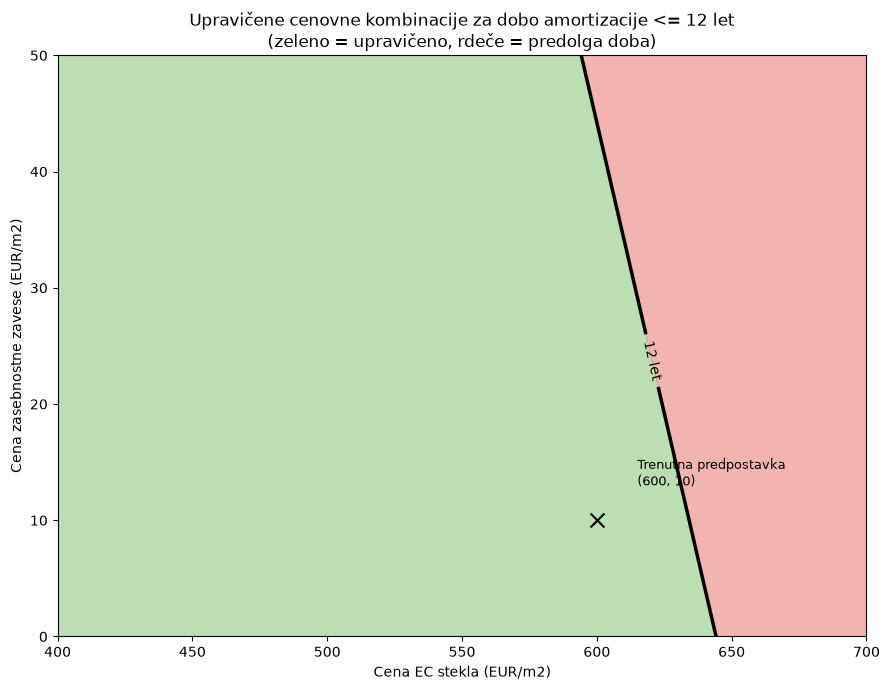

In [21]:
# ============================================================
# GRAF -- upravičene cene EC stekla in zavese, za dobo amortizacije <= 15 let
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

target_payback_years = 12

# Razpon cen za preizkus
ec_glass_prices = np.linspace(400, 700, 100)      # EUR/m2, EC steklo
curtain_normal_prices = np.linspace(0, 50, 100)   # EUR/m2, zasebnostna zavesa

# Fiksni parametri (iz Cell 20 -- se ne spreminjajo)
cost_A_fixed = cost_A_eur_m2   # navadno steklo + blackout zavesa

payback_grid = np.zeros((len(curtain_normal_prices), len(ec_glass_prices)))
for i, curtain_price in enumerate(curtain_normal_prices):
    for j, ec_price in enumerate(ec_glass_prices):
        cost_B_per_m2 = ec_price + curtain_price
        extra_per_m2 = cost_B_per_m2 - cost_A_fixed
        investment = extra_per_m2 * glazing_area + fixed_installation_cost_eur
        if investment > 0 and net_annual_savings_eur > 0:
            payback_grid[i, j] = investment / net_annual_savings_eur
        else:
            payback_grid[i, j] = 0

fig, ax = plt.subplots(figsize=(9, 7))

contour_fill = ax.contourf(ec_glass_prices, curtain_normal_prices, payback_grid,
                             levels=[0, target_payback_years, payback_grid.max()],
                             colors=["#8FC97F", "#E8827A"], alpha=0.6)

contour_line = ax.contour(ec_glass_prices, curtain_normal_prices, payback_grid,
                            levels=[target_payback_years], colors="black", linewidths=2.5)
ax.clabel(contour_line, fmt=f"{target_payback_years} let", fontsize=10)

# Oznaci trenutno predpostavko (iz Cell 20)
ax.scatter([glass_price_spd_eur_m2], [curtain_price_privacy_eur_m2], color="black", zorder=5, s=100, marker="x")
ax.annotate(f"Trenutna predpostavka\n({glass_price_spd_eur_m2:.0f}, {curtain_price_privacy_eur_m2:.0f})",
            xy=(glass_price_spd_eur_m2, curtain_price_privacy_eur_m2),
            xytext=(glass_price_spd_eur_m2+15, curtain_price_privacy_eur_m2+3), fontsize=9)

ax.set_xlabel("Cena EC stekla (EUR/m2)")
ax.set_ylabel("Cena zasebnostne zavese (EUR/m2)")
ax.set_title(f"Upravičene cenovne kombinacije za dobo amortizacije <= {target_payback_years} let\n(zeleno = upravičeno, rdeče = predolga doba)")
plt.tight_layout()
plt.show()